<p dir="rtl" style="font-family:shabnam;font-size:24px;color:#6199f2;">ایمپورت کردن کتابخانه </p>


In [1]:
from sklearn.datasets import fetch_lfw_people
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans 
from sklearn.mixture import GaussianMixture



<p dir="rtl" style="font-family:shabnam;font-size:24px;color:#6199f2;">گام اول – بارگذاری مجموعه داده و تحلیل اولیه</p>


In [2]:
lfw = fetch_lfw_people(min_faces_per_person=70 , resize=0.4)

In [3]:
x = lfw.data
y = lfw.target
classes = lfw.target_names


In [4]:
print(x)
print("numbers : ",len(x))
print("-----------------------------")
print(y)
print(np.max(y))
print("numbers : ",len(y))
print("-----------------------------")
print(classes)
print("numbers : ",len(classes))

[[0.9973857  0.99607843 0.9921568  ... 0.38169935 0.38823533 0.3803922 ]
 [0.14771242 0.19738562 0.1751634  ... 0.45751634 0.44444445 0.53594774]
 [0.34379086 0.39477125 0.49150327 ... 0.709804   0.72156864 0.7163399 ]
 ...
 [0.3633987  0.3372549  0.30718955 ... 0.19738562 0.22091503 0.19346406]
 [0.19346406 0.24705882 0.34248367 ... 0.7346406  0.6640523  0.6117647 ]
 [0.11633987 0.10196079 0.1267974  ... 0.13333334 0.13725491 0.2535948 ]]
numbers :  1288
-----------------------------
[5 6 3 ... 5 3 5]
6
numbers :  1288
-----------------------------
['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']
numbers :  7


In [5]:
x.shape

(1288, 1850)

In [6]:
lfw.images[0].shape

(50, 37)

In [7]:
ttt = pd.DataFrame(lfw.target)
ttt.value_counts()

0
3    530
1    236
6    144
2    121
4    109
0     77
5     71
Name: count, dtype: int64

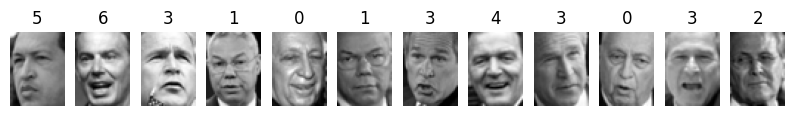

In [8]:
plt.figure(figsize=(10,4))

for i in range(12):
    plt.subplot(1, 12, i+1)
    plt.imshow(lfw.images[i], cmap="gray")
    # plt.title(lfw.names[i])
    plt.title(lfw.target[i])
    plt.axis("off")



----------------

<p dir="rtl" style="font-family:shabnam;font-size:24px;color:#6199f2;">گام دوم–پیش پردازش</p>


In [9]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

x

array([[0.9973857 , 0.99607843, 0.9921568 , ..., 0.38169935, 0.38823533,
        0.3803922 ],
       [0.14771242, 0.19738562, 0.1751634 , ..., 0.45751634, 0.44444445,
        0.53594774],
       [0.34379086, 0.39477125, 0.49150327, ..., 0.709804  , 0.72156864,
        0.7163399 ],
       ...,
       [0.3633987 , 0.3372549 , 0.30718955, ..., 0.19738562, 0.22091503,
        0.19346406],
       [0.19346406, 0.24705882, 0.34248367, ..., 0.7346406 , 0.6640523 ,
        0.6117647 ],
       [0.11633987, 0.10196079, 0.1267974 , ..., 0.13333334, 0.13725491,
        0.2535948 ]], shape=(1288, 1850), dtype=float32)

In [10]:
x

array([[0.9973857 , 0.99607843, 0.9921568 , ..., 0.38169935, 0.38823533,
        0.3803922 ],
       [0.14771242, 0.19738562, 0.1751634 , ..., 0.45751634, 0.44444445,
        0.53594774],
       [0.34379086, 0.39477125, 0.49150327, ..., 0.709804  , 0.72156864,
        0.7163399 ],
       ...,
       [0.3633987 , 0.3372549 , 0.30718955, ..., 0.19738562, 0.22091503,
        0.19346406],
       [0.19346406, 0.24705882, 0.34248367, ..., 0.7346406 , 0.6640523 ,
        0.6117647 ],
       [0.11633987, 0.10196079, 0.1267974 , ..., 0.13333334, 0.13725491,
        0.2535948 ]], shape=(1288, 1850), dtype=float32)

In [11]:
print(f"{np.std(x_scaled):.2f}")
print(f"{np.mean(x_scaled):.2f}")

1.00
-0.00


-----------

یه مثال برای اینکه داده های خود را استاندارد نکنیم


In [12]:
exa = pd.DataFrame(np.array([[1.5,50] , 
                [1.6,60],
                [1.7,70],
                [1.8,80],
                [1.9,90]]) ,  columns=["f1" , "f2"])

exa

,f1,f2
0,1.5,50.0
1,1.6,60.0
2,1.7,70.0
3,1.8,80.0
4,1.9,90.0


In [13]:
exa_pca = PCA()
exa_pca.fit(exa)
print(exa_pca.explained_variance_)


[2.50025000e+02 7.09903824e-33]


-----------

<p dir="rtl" style="font-family:shabnam;font-size:24px;color:#6199f2;">گام سوم–اجرایPCAو تحلیل واریانس</p>


In [14]:
pca_Full = PCA()
pca_Full.fit_transform(x_scaled)



cumulative_variance = np.cumsum(pca_Full.explained_variance_ratio_)
dddd = pd.DataFrame(cumulative_variance)
dddd

,0
0,0.256733
1,0.401700
2,0.470743
3,0.520919
4,0.553216
...,...
1283,1.000000
1284,1.000000
1285,1.000000
1286,1.000000


In [15]:
cumulative_variance[100]

np.float32(0.9112408)

In [16]:
kk = np.where(cumulative_variance >= 0.9)[0][0]
kk

np.int64(88)

Text(0, 0.5, 'Cumulative')

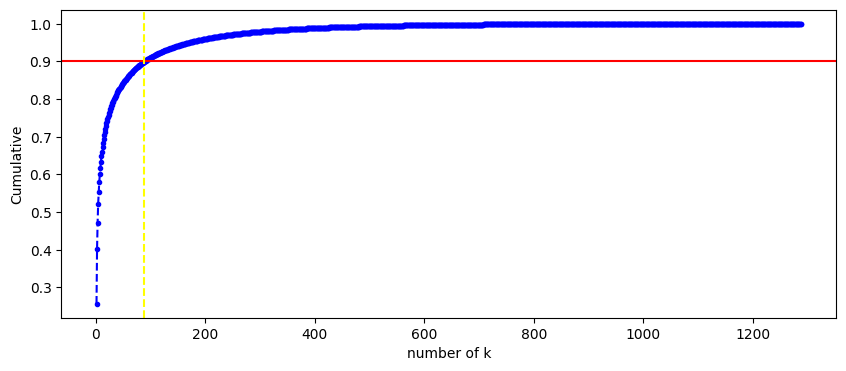

In [17]:
plt.figure(figsize=(10,4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='.', linestyle='--', color='b')
plt.axhline(0.9 , color="red" , linestyle="-")
plt.axvline(kk , color="yellow" , linestyle="--")
plt.xlabel("number of k")
plt.ylabel("Cumulative")

In [18]:
pca_dataframe = pd.DataFrame((pca_Full.explained_variance_ratio_) ,columns=["pov"])
pca_dataframe


,pov
0,2.567332e-01
1,1.449665e-01
2,6.904362e-02
3,5.017542e-02
4,3.229721e-02
...,...
1283,1.742346e-07
1284,1.666433e-07
1285,1.572894e-07
1286,1.313195e-07


In [19]:
pca_dataframe[pca_dataframe["pov"] >= 0.01].round(2)

,pov
0,0.26
1,0.14
2,0.07
3,0.05
4,0.03
5,0.03
6,0.02
7,0.02
8,0.02
9,0.02


In [20]:
cumulative_variance

array([0.25673324, 0.40169975, 0.47074336, ..., 1.0000002 , 1.0000004 ,
       1.0000004 ], shape=(1288,), dtype=float32)

<p dir="rtl" style="font-family:shabnam;font-size:24px;color:#6199f2;">گام چهارم–خوشه بندیK-Meansو تعیینKمناسب</p>


In [21]:
pca_90 = PCA(n_components=0.9)

x_reduce = pca_90.fit_transform(x_scaled)

x_reduce.shape

(1288, 89)

1. n_components=0.80 ----> (1288, 34)
2. n_components=0.85 ----> (1288, 54)
3. n_components=0.90 ----> (1288, 89)
4. n_components=0.95 ----> (1288, 171)
5. n_components=120  ----> (1288, 120)

In [22]:
Inertia=[]
silhouette_val=[]
n_k = np.array(np.arange(2,30))


for k in (n_k):
    kmeans = KMeans(n_clusters=k , n_init=20 , random_state=42)
    kmeans.fit(x_reduce)
    Inertia.append(kmeans.inertia_)

    score = silhouette_score(x_reduce , kmeans.labels_)
    silhouette_val.append(score)

# plt.figure(figsize=(10,5))

# plt.subplot(1,2,1)
# plt.plot(n_k , Inertia , marker="o")
# plt.title("elbow method")
# plt.xlabel("number of clustering")
# plt.ylabel("Inertia")

# plt.subplot(1,2,2)
# plt.plot(n_k , silhouette_val , marker=".")
# plt.title("silhouette_score method")
# plt.xlabel("number of clustering")
# plt.ylabel("silhouette")



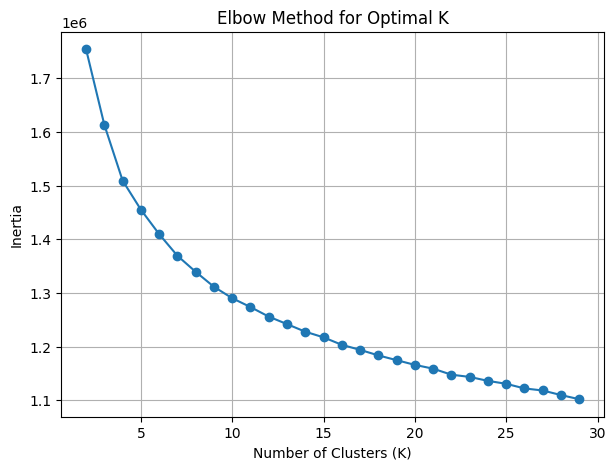

In [23]:
plt.figure(figsize=(7, 5))
plt.plot(n_k, Inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.show()


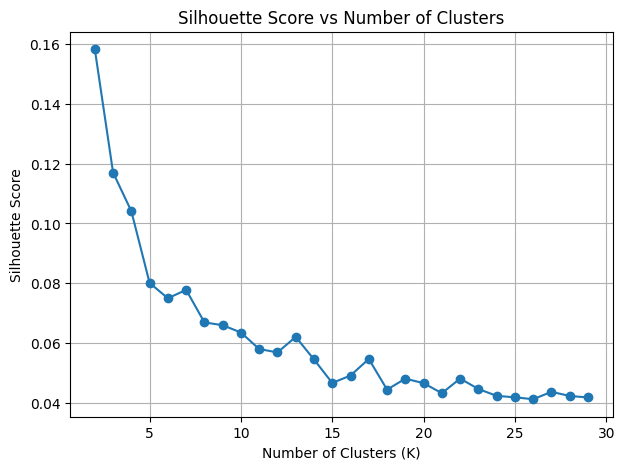

In [24]:
plt.figure(figsize=(7, 5))
plt.plot(n_k, silhouette_val, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.grid(True)
plt.show()


------------------------

In [25]:
K_FINAL = 4  

kmeans_final = KMeans(n_clusters=K_FINAL , n_init=20)
kmeans_labels = kmeans_final.fit_predict(x_reduce)



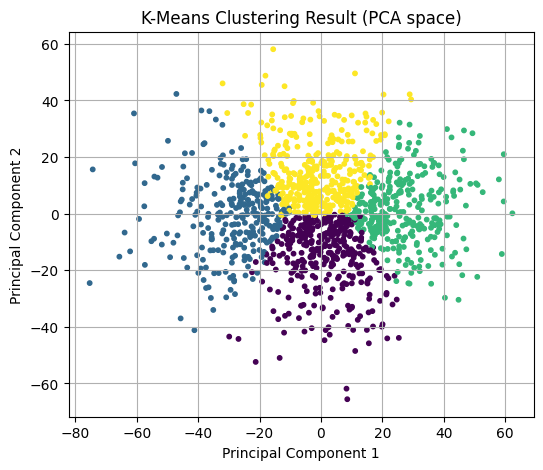

In [26]:
plt.figure(figsize=(6, 5))
plt.scatter(x_reduce[:, 0], x_reduce[:, 1], c=kmeans_labels, s=10)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering Result (PCA space)")
plt.grid(True)
plt.show()


برای نمایش عکس ها به تعداد 15 از چت چی پی تی استفاده کردم که بهتر بتونم اطلاعات رو نمایش بدم


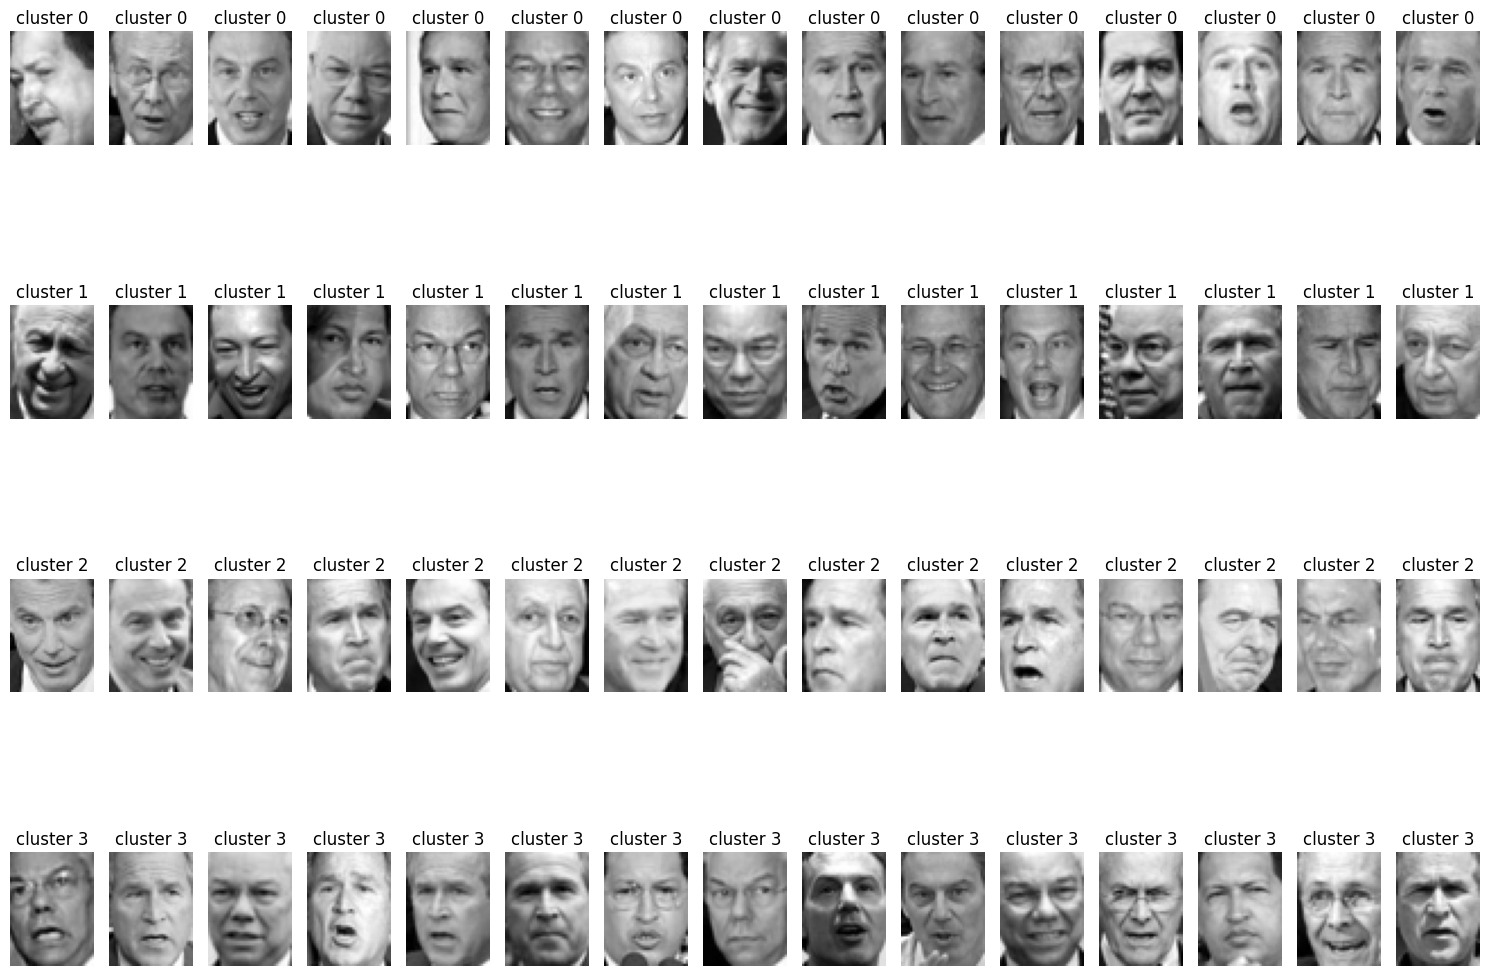

In [27]:
n_images_per_cluster = 15
plt.figure(figsize=(15, K_FINAL * 3)) 


for cluster_id in range(K_FINAL):
    indices = np.where(kmeans_labels == cluster_id)[0]
    
    sample_indices = np.random.choice(indices, size=min(n_images_per_cluster, len(indices)), replace=False)
    
    for i, sample_idx in enumerate(sample_indices):
        plt.subplot(K_FINAL, n_images_per_cluster, cluster_id * n_images_per_cluster + i + 1)
        plt.imshow(lfw.images[sample_idx], cmap='gray') 
        plt.title(f"cluster {cluster_id}")
        plt.axis('off')
            

plt.tight_layout()
plt.show()

In [28]:
final_inertia = kmeans_final.inertia_
print("Final K-Means Inertia:", final_inertia)


Final K-Means Inertia: 1509274.25


In [29]:
final_silhouette = silhouette_score(x_reduce, kmeans_labels)
print("Final K-Means Silhouette Score:", final_silhouette)


Final K-Means Silhouette Score: 0.10407233238220215


In [30]:
kmeans_final_reconstruction_error_mse = np.mean((x_reduce - kmeans_final.cluster_centers_[kmeans_labels]) ** 2)
print(f"MSE Reconstruction Error: {kmeans_final_reconstruction_error_mse:.4f}")

MSE Reconstruction Error: 13.1663


-----------

<p dir="rtl" style="font-family:shabnam;font-size:24px;color:#6199f2;">گام پنجم–اجرای الگوریتمEMو مقایسه باK-Means</p>


In [31]:
# gmm = GaussianMixture(n_components=K_FINAL, covariance_type='full', random_state=42) --- silhouette= 0.05 
gmm = GaussianMixture(n_components=K_FINAL, covariance_type='spherical', random_state=42)
gmm.fit(x_reduce)

labels_em = gmm.predict(x_reduce)

In [32]:
gmm_silhouette = silhouette_score(x_reduce, labels_em)
gmm_silhouette

0.10361974686384201

In [33]:
log_likelihood = gmm.score(x_reduce) * x_reduce.shape[0]
print("Log Likelihood:", log_likelihood)

Log Likelihood: -312114.56


In [34]:
responsibilities = gmm.predict_proba(x_reduce)

gmm_reconstruction_error = np.mean((x_reduce - responsibilities @ gmm.means_) ** 2)
print("GMM Reconstruction Error:", gmm_reconstruction_error)


GMM Reconstruction Error: 13.029063


In [35]:
print("K-Means Inertia:", final_inertia)
print("K-Means Silhouette:", final_silhouette)
print("kmeans Reconstruction Error", kmeans_final_reconstruction_error_mse)

print("GMM Log Likelihood:", log_likelihood)
print("GMM Silhouette:", gmm_silhouette)
print("GMM Reconstruction Error:", gmm_reconstruction_error)


K-Means Inertia: 1509274.25
K-Means Silhouette: 0.10407233238220215
kmeans Reconstruction Error 13.166255
GMM Log Likelihood: -312114.56
GMM Silhouette: 0.10361974686384201
GMM Reconstruction Error: 13.029063


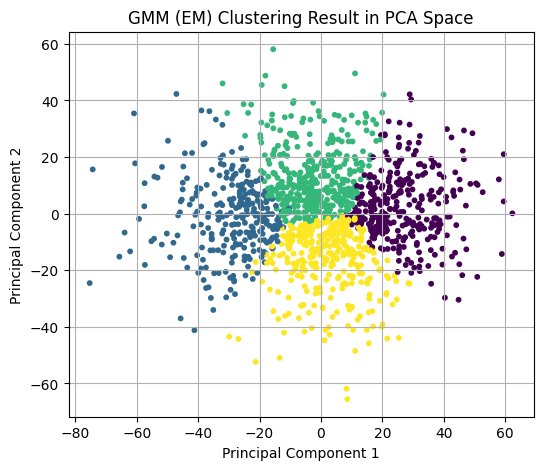

In [36]:
plt.figure(figsize=(6, 5))
plt.scatter(x_reduce[:, 0], x_reduce[:, 1], c=labels_em, s=10)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("GMM (EM) Clustering Result in PCA Space")
plt.grid(True)
plt.show()


---------

<p dir="rtl" style="font-family:shabnam;font-size:24px;color:#6199f2;">گام ششم–تحلیل نهایی و ترسیم بصری</p>


In [37]:
lfw.images.shape


(1288, 50, 37)

In [38]:
_, h, w = lfw.images.shape
n_components_selected = pca_90.n_components_
n_components_selected


np.int64(89)

In [39]:
eigenfaces = pca_90.components_.reshape((n_components_selected, h, w))
eigenfaces

array([[[ 0.00673693,  0.00785911,  0.0097152 , ...,  0.00929519,
          0.00775887,  0.00720478],
        [ 0.00717183,  0.008616  ,  0.01103921, ...,  0.01029896,
          0.0085271 ,  0.00797413],
        [ 0.00818471,  0.00997872,  0.01258359, ...,  0.0115639 ,
          0.00912548,  0.00832486],
        ...,
        [ 0.00179958,  0.00168863,  0.00310951, ...,  0.00632317,
          0.00546523,  0.00458819],
        [ 0.00207458,  0.00211836,  0.00300172, ...,  0.00619914,
          0.00519833,  0.00427219],
        [ 0.00249932,  0.00254644,  0.00305838, ...,  0.00579266,
          0.00518851,  0.00407724]],

       [[-0.01670311, -0.01617733, -0.01820815, ...,  0.01729065,
          0.01692672,  0.01658996],
        [-0.01689372, -0.0170196 , -0.02082258, ...,  0.01838125,
          0.01805407,  0.01744588],
        [-0.01734556, -0.01886308, -0.02370332, ...,  0.01977479,
          0.0190697 ,  0.01856689],
        ...,
        [-0.00930655, -0.01087226, -0.01148618, ...,  

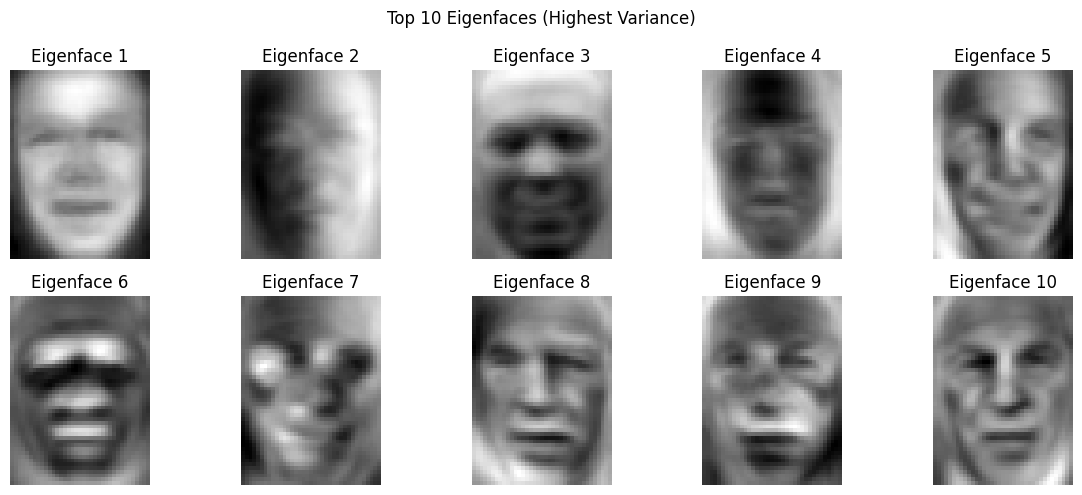

In [40]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[i], cmap='gray')
    ax.set_title(f"Eigenface {i+1}")
    ax.axis('off')

plt.suptitle("Top 10 Eigenfaces (Highest Variance)")
plt.tight_layout()
plt.show()


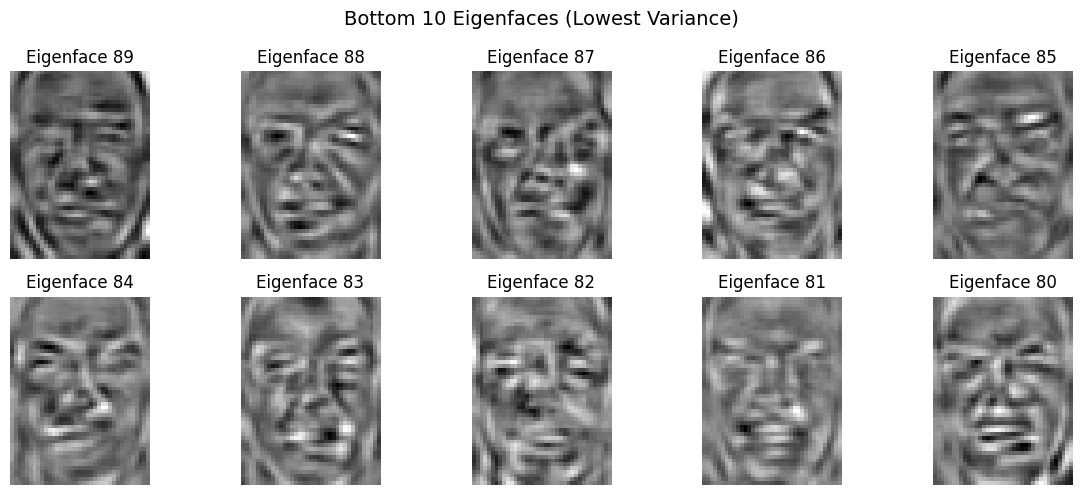

In [41]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[-(i+1)], cmap='gray')
    ax.set_title(f"Eigenface {n_components_selected - i}")
    ax.axis('off')

plt.suptitle("Bottom 10 Eigenfaces (Lowest Variance)", fontsize=14)
plt.tight_layout()
plt.show()
